In [ ]:
from pathlib import Path
import h5py
from PIL import Image
import io
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# downloaded arx-x5_clean_50.zip and exatracted to ../data/ folder from https://huggingface.co/datasets/TianxingChen/RoboTwin2.0/tree/main/dataset/click_bell
p = Path("../data/arx-x5_clean_50/data/episode0.hdf5")
x = h5py.File(p)

In [ ]:
# <KeysViewHDF5 ['endpose', 'joint_action', 'observation', 'pointcloud', 'third_view_rgb']>

# joint_action:
#<KeysViewHDF5 ['left_arm', 'left_gripper', 'right_arm', 'right_gripper', 'vector']>

#x['joint_action']['left_arm'].shape # (53, 6)
#x['joint_action']['left_gripper'].shape # (53,)
#x['joint_action']['right_arm'].shape # (53, 6)
#x['joint_action']['right_gripper'].shape (53,)
#x['joint_action']['vector'].shape # (53, 14)

# 7 elements of endpose are 3d pos + quaternion for rotation: x, y, z, qw, qx, qy, qz
# x['endpose']['left_endpose']
# x['endpose']['left_gripper']
# x['endpose']['right_endpose']
# x['endpose']['right_gripper']

print("left:")
print("begin joints:", x['joint_action']['left_arm'][0:3])
print("end joints:", x['joint_action']['left_arm'][-3:])
print("right:")
print("begin joints:", x['joint_action']['right_arm'][0:3])
print("end joints:", x['joint_action']['right_arm'][-3:])


left:
begin joints: [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -1.99999995e-05  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-6.51226845e-03  1.44575527e-02  1.43387066e-02 -1.22978734e-02
  -5.47983774e-08 -6.50950568e-03]]
end joints: [[-6.63212419e-01  2.03998661e+00  1.71319795e+00 -1.22388566e+00
  -6.88263623e-04 -6.59090281e-01]
 [-6.62767112e-01  2.03228951e+00  1.74704826e+00 -1.26452661e+00
  -6.86921005e-04 -6.58622086e-01]
 [-6.62611842e-01  2.03111434e+00  1.75034177e+00 -1.26784098e+00
  -6.86648535e-04 -6.58469498e-01]]
right:
begin joints: [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
end joints: [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


(53, 6)

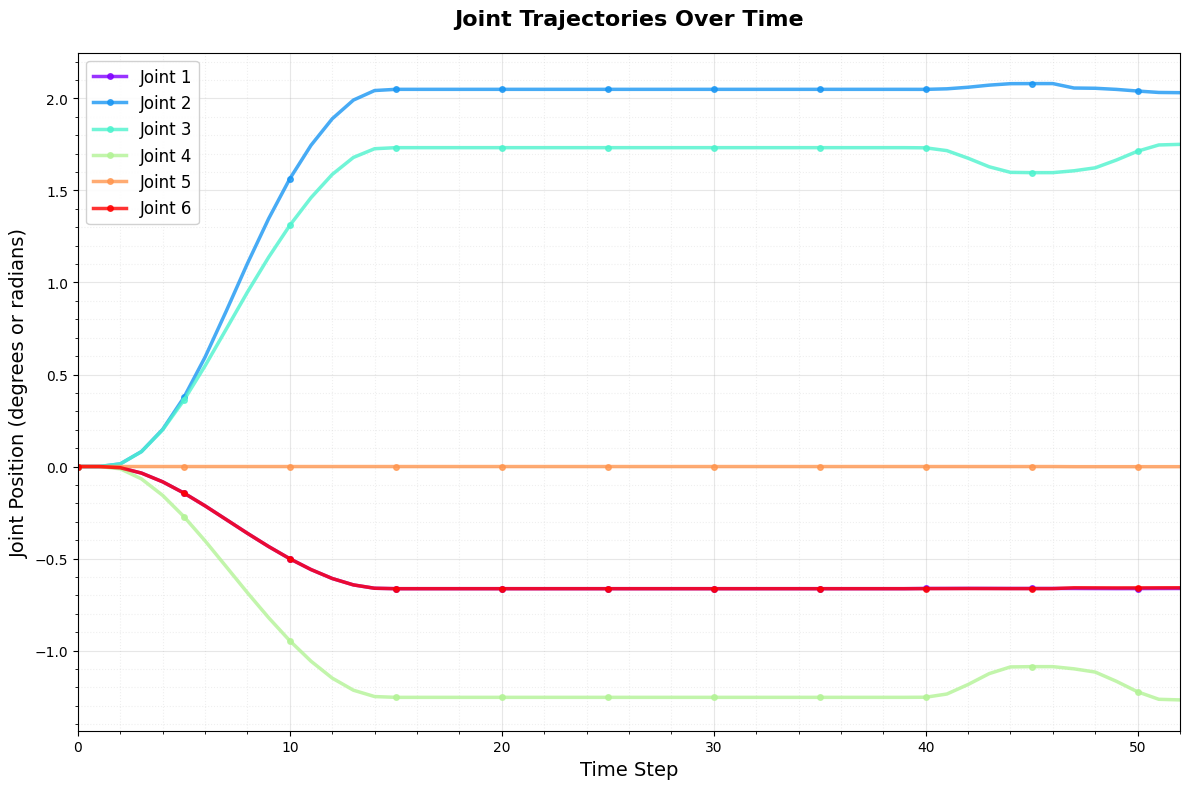

In [ ]:
# plot left arm joint curves
joint_data = x['joint_action']['left_arm']
time_steps, num_joints = joint_data.shape

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each joint trajectory
colors = plt.cm.rainbow(np.linspace(0, 1, num_joints))
for i in range(num_joints):
    ax.plot(range(time_steps), joint_data[:, i], 
            label=f'Joint {i+1}', 
            linewidth=2.5, 
            color=colors[i],
            marker='o', 
            markevery=5,  # Show markers every 5 points
            markersize=4,
            alpha=0.8)
    
# Customize the plot
ax.set_xlabel('Time Step', fontsize=14)
ax.set_ylabel('Joint Position (degrees or radians)', fontsize=14)
ax.set_title('Joint Trajectories Over Time', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, time_steps-1])

# Add minor gridlines
ax.minorticks_on()
ax.grid(which='minor', alpha=0.2, linestyle=':')

# Tight layout for better appearance
plt.tight_layout()

# Display the plot
plt.show()

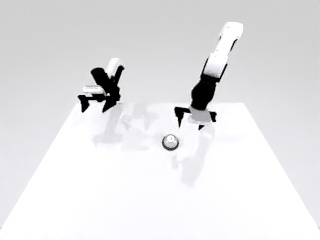

In [45]:
Image.open(io.BytesIO(x['third_view_rgb'][10]))

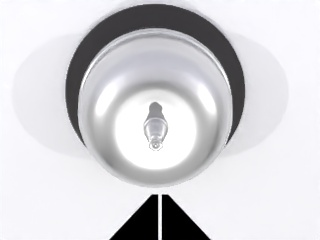

In [59]:
# x['observation']: <KeysViewHDF5 ['head_camera', 'left_camera', 'right_camera']>
# each cam has: <KeysViewHDF5 ['cam2world_gl', 'extrinsic_cv', 'intrinsic_cv', 'rgb']>

Image.open(io.BytesIO(x['observation']['left_camera']['rgb'][-1]))

In [ ]:
# path planning trajectory data with position and pvelocity
traj_path = Path("../data/arx-x5_clean_50/_traj_data/episode0.pkl")
with traj_path.open("rb") as f:
    tx = pickle.load(f)
num_trajectories = len(tx['left_joint_path'])
print(num_trajectories)
print(tx['left_joint_path'][0].keys())

3
dict_keys(['status', 'position', 'velocity'])
